In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os

# Гарантируем путь к папке data/raw
DATA_DIR = os.path.join(os.getcwd(), "data", "raw")
os.makedirs(DATA_DIR, exist_ok=True)

np.random.seed(42)
n_orders = 10_000

data = {
    'order_id': range(1, n_orders + 1),
    'order_date': pd.date_range('2024-01-01', periods=n_orders, freq='H'),
    'warehouse_id': np.random.choice(['WH_Moscow', 'WH_SPb', 'WH_Kazan'], n_orders),
    'destination_city': np.random.choice(['Moscow', 'SPb', 'Kazan', 'Ekaterinburg', 'Novosibirsk'], n_orders),
    'distance_km': np.random.exponential(scale=300, size=n_orders).round(1),
    'carrier': np.random.choice(['CDEK', 'Boxberry', 'PickPoint', 'Russian Post'], n_orders),
    'estimated_delivery_days': np.random.randint(1, 6, n_orders),
    'weight_kg': np.random.exponential(scale=2.5, size=n_orders).round(2),
    'delivered': np.random.choice([True, False], n_orders, p=[0.92, 0.08]),
}

df = pd.DataFrame(data)

base_cost_per_km = {'CDEK': 15, 'Boxberry': 12, 'PickPoint': 10, 'Russian Post': 8}
df['freight_cost'] = df.apply(
    lambda row: row['distance_km'] * base_cost_per_km[row['carrier']] * (1 + row['weight_kg'] * 0.1), axis=1
).round(2)

df['actual_delivery_days'] = df.apply(
    lambda row: row['estimated_delivery_days'] + np.random.choice([0, 1, 2, 3], p=[0.8, 0.1, 0.07, 0.03]) 
    if row['delivered'] else np.nan, axis=1
)
df['delay_days'] = df['actual_delivery_days'] - df['estimated_delivery_days']
df['delay_days'] = df['delay_days'].apply(lambda x: max(0, x) if pd.notna(x) else np.nan)

# Сохраняем CSV и SQLite
csv_path = os.path.join(DATA_DIR, 'logistics_data.csv')
db_path = os.path.join(DATA_DIR, 'logistics.db')

df.to_csv(csv_path, index=False)
import sqlite3
conn = sqlite3.connect(db_path)
df.to_sql('deliveries', conn, index=False, if_exists='replace')
conn.close()

print(f"✅ Сгенерировано {len(df)} записей")
print(f"📁 CSV: {csv_path}")
print(f"🗄️ DB: {db_path}")

C:\Users\user\AppData\Local\Temp\ipykernel_4792\181505454.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'order_date': pd.date_range('2024-01-01', periods=n_orders, freq='H'),


✅ Сгенерировано 10000 записей
📁 CSV: c:\Users\user\AppData\Local\Programs\Microsoft VS Code\data\raw\logistics_data.csv
🗄️ DB: c:\Users\user\AppData\Local\Programs\Microsoft VS Code\data\raw\logistics.db


📊 Первые 5 строк:


,order_id,order_date,warehouse_id,destination_city,distance_km,carrier,estimated_delivery_days,weight_kg,delivered,freight_cost,actual_delivery_days,delay_days
0,1,2024-01-01 00:00:00,WH_Kazan,SPb,331.3,Russian Post,3,1.53,True,3055.91,3.0,0.0
1,2,2024-01-01 01:00:00,WH_Moscow,SPb,147.5,Russian Post,3,1.58,True,1366.44,3.0,0.0
2,3,2024-01-01 02:00:00,WH_Kazan,Ekaterinburg,88.4,PickPoint,1,4.05,True,1242.02,1.0,0.0
3,4,2024-01-01 03:00:00,WH_Kazan,Moscow,152.8,CDEK,5,6.20,True,3713.04,5.0,0.0
4,5,2024-01-01 04:00:00,WH_Moscow,SPb,494.6,Russian Post,1,0.21,True,4039.89,1.0,0.0



📋 Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   order_id                 10000 non-null  int64         
 1   order_date               10000 non-null  datetime64[ns]
 2   warehouse_id             10000 non-null  object        
 3   destination_city         10000 non-null  object        
 4   distance_km              10000 non-null  float64       
 5   carrier                  10000 non-null  object        
 6   estimated_delivery_days  10000 non-null  int32         
 7   weight_kg                10000 non-null  float64       
 8   delivered                10000 non-null  bool          
 9   freight_cost             10000 non-null  float64       
 10  actual_delivery_days     9229 non-null   float64       
 11  delay_days               9229 non-null   float64       
dtypes: bool(1

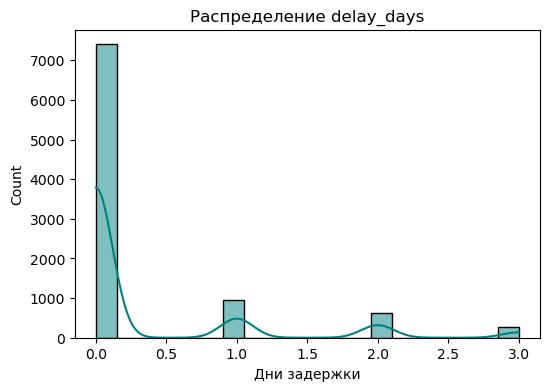

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Первые 5 строк:")
display(df.head())

print("\n📋 Информация о данных:")
df.info()

print("\n📈 Распределение задержек:")
plt.figure(figsize=(6,4))
sns.histplot(df[df['delay_days'].notna()]['delay_days'], bins=20, kde=True, color='teal')
plt.title('Распределение delay_days')
plt.xlabel('Дни задержки')
plt.show()